In [28]:
import numpy as np
import numba as nb
import healpy as hp
import matplotlib.pyplot as plt
from astropy.coordinates import EarthLocation, SkyCoord, AltAz

# SINGLE MAP

In [29]:
path_map = '/scratch/thomasb/map_test.npz'
path_map2 = '/scratch/thomasb/mapmaking_dumps/version2/average_mapgpu_sat0.npz'
path_map3 = '/scratch/thomasb/mapmaking_dumps/version2/average_mapcpu_testoldata.npz'
path_map4 = '/scratch/thomasb/mapmaking_dumps/version2/average_mapgpu_testoldata.npz'

with np.load(path_map2) as f:
    print(f)
    map2 = f['avg_map']

with np.load(path_map3) as f:
    print(f)
    map3 = f['avg_map']

with np.load(path_map4) as f:
    print(f)
    map4 = f['avg_map']

NpzFile '/scratch/thomasb/mapmaking_dumps/version2/average_mapgpu_sat0.npz' with keys: avg_map, NSIDE, n_maps
NpzFile '/scratch/thomasb/mapmaking_dumps/version2/average_mapcpu_testoldata.npz' with keys: avg_map, NSIDE, n_maps
NpzFile '/scratch/thomasb/mapmaking_dumps/version2/average_mapgpu_testoldata.npz' with keys: avg_map, NSIDE, n_maps


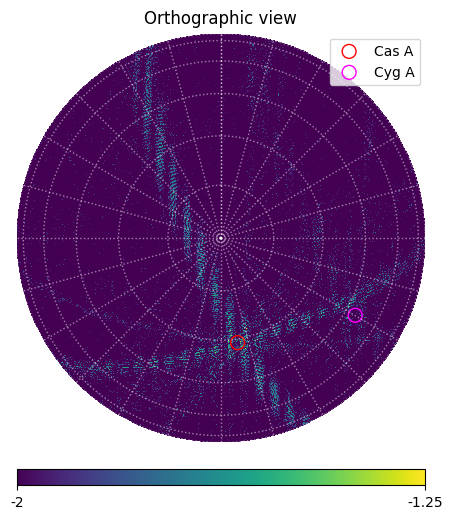

In [30]:
hp.orthview(np.log10(np.abs(map3)),min=-2,max=-1.25, rot=(0,90),half_sky=True)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A

hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')

plt.legend()
plt.show()

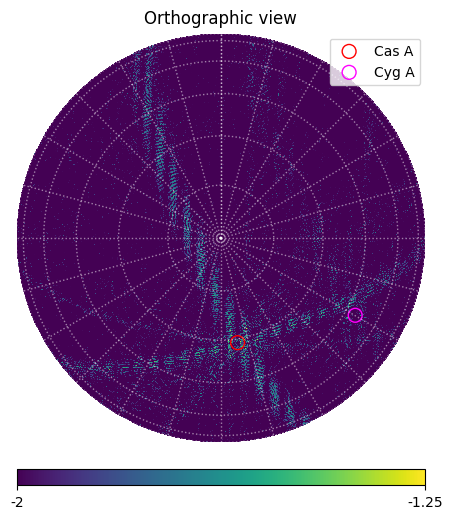

In [31]:
hp.orthview(np.log10(np.abs(map4)),min=-2,max=-1.25, rot=(0,90),half_sky=True)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A

hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')

plt.legend()
plt.show()

In [32]:
np.max(np.abs(map3))
np.max(np.abs(map4))

np.float32(0.08423303)

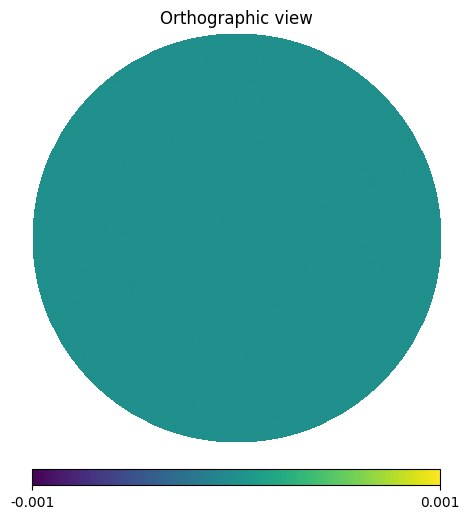

In [33]:
hp.orthview(map3-map4,min=-1e-3,max=1e-3, rot=(0,90),half_sky=True)

In [34]:
map3

array([ 0.00586928,  0.00092279,  0.00124137, ...,  0.00135003,
        0.00010944, -0.0012682 ], shape=(786432,), dtype=float32)

(array([1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 0.0000e+00, 2.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 7.0000e+00, 2.0000e+00,
        3.0000e+00, 4.0000e+00, 2.0000e+00, 6.0000e+00, 1.2000e+01,
        8.0000e+00, 1.1000e+01, 8.0000e+00, 1.5000e+01, 2.4000e+01,
        2.9000e+01, 2.3000e+01, 2.8000e+01, 3.9000e+01, 5.4000e+01,
        5.5000e+01, 6.6000e+01, 7.2000e+01, 7.8000e+01, 8.1000e+01,
        1.0700e+02, 1.1800e+02, 1.3900e+02, 1.5100e+02, 1.5300e+02,
        1.9800e+02, 1.8400e+02, 2.3200e+02, 2.9600e+02, 3.4300e+02,
        3.5500e+02, 4.1900e+02, 4.4500e+02, 5.3500e+02, 5.9000e+02,
        6.6400e+02, 7.6600e+02, 8.1800e+02, 1.0030e+03, 9.9800e+02,
        1.1410e+03, 1.3150e+03, 1.4240e+03, 1.5780e+03, 1.7320e+03,
        1.8900e+03, 2.1290e+03, 2.4050e+03, 2.55

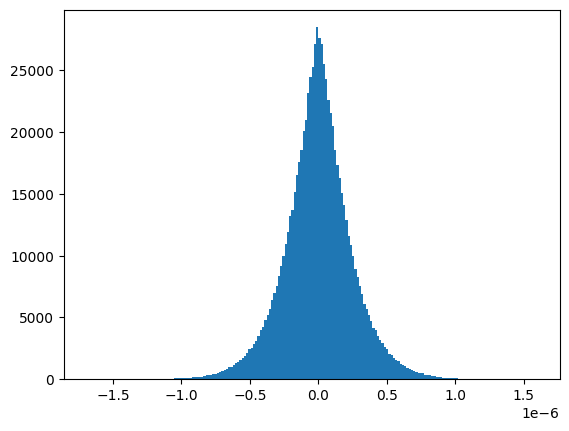

In [36]:
plt.hist(map3-map4, bins=200)

In [43]:
path_map = f'/scratch/thomasb/mapmaking_dump1/satpass_1.npz'


with np.load(path_map) as f:
    print(f)
    vis = f['vis']
    mask = f['mask']
    times = f['times']
    freqs = f['freqs']

NpzFile '/scratch/thomasb/mapmaking_dump1/satpass_1.npz' with keys: vis, mask, times, freqs


In [44]:
print(vis.shape)
print(mask.shape)
print(times.shape)
print(freqs.shape)

(245, 2048, 21)
(245, 2048, 21)
(245,)
(2048,)


In [20]:
fringes = np.load('/scratch/thomasb/mapmaking_dumps/fringes1.npy')
fringes.shape

(21, 12582912)

In [21]:
fringes.real[0]

array([-0.16435647, -0.16127698, -0.24593648, ..., -0.25536306,
       -0.17087597, -0.16779945], shape=(12582912,))

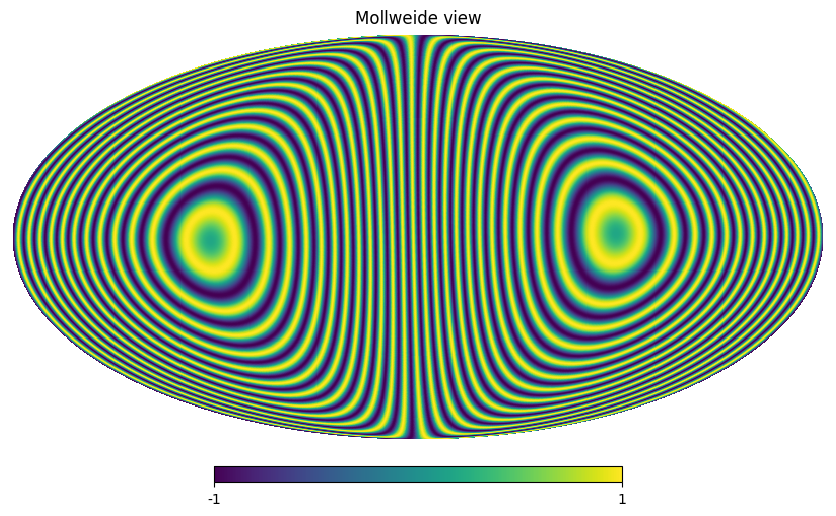

In [22]:
hp.mollview(fringes[0,:].real)